In [ ]:
!pip install -q diffusers transformers accelerate
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not detected")


CUDA available: True
GPU: Tesla T4


In [ ]:
import os
import torch
from diffusers import StableDiffusionPipeline


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16
).to(DEVICE)

pipe.enable_attention_slicing()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [ ]:
labels_prompts = {
    "normal": "Chest X-ray, frontal PA view, healthy lungs, clear lung fields, grayscale medical radiograph, clinical realism",

    "fracture": "Chest X-ray showing rib fracture, cortical bone disruption, trauma radiograph, grayscale medical image",

    "pneumonia": "Chest X-ray, bacterial pneumonia, lobar consolidation, increased lung opacity, radiology image",

    "covid": "Chest X-ray, bilateral ground-glass opacities, COVID-19 pneumonia pattern, grayscale radiograph",

    "pneumothorax": "Chest X-ray, pneumothorax, collapsed lung, visible pleural line, radiology image",

    "pleural_effusion": "Chest X-ray, pleural effusion, blunted costophrenic angle, fluid accumulation",

    "cardiomegaly": "Chest X-ray, enlarged cardiac silhouette, cardiomegaly, clinical radiograph",

    "fibrosis": "Chest X-ray, pulmonary fibrosis, reticular opacities, reduced lung volume"
}


In [ ]:
OUTPUT_DIR = "xray_disease_prediction_dataset"
IMAGES_PER_LABEL = 5

os.makedirs(OUTPUT_DIR, exist_ok=True)

for label, prompt in labels_prompts.items():
    label_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(label_dir, exist_ok=True)

    print(f"Generating images for: {label}")

    for i in range(1, IMAGES_PER_LABEL + 1):
        image = pipe(
            prompt,
            guidance_scale=7.5,
            num_inference_steps=40
        ).images[0]

        image_path = os.path.join(label_dir, f"{label}_{i}.png")
        image.save(image_path)

        print(f"Saved: {image_path}")

print("\n✅ Dataset generation completed successfully!")


Generating images for: normal


  0%|          | 0/40 [00:00<?, ?it/s]

Saved: xray_disease_prediction_dataset/normal/normal_1.png


  0%|          | 0/40 [00:00<?, ?it/s]

Saved: xray_disease_prediction_dataset/normal/normal_2.png


...

  0%|          | 0/40 [00:00<?, ?it/s]

Saved: xray_disease_prediction_dataset/fibrosis/fibrosis_4.png


  0%|          | 0/40 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


Saved: xray_disease_prediction_dataset/fibrosis/fibrosis_5.png

✅ Dataset generation completed successfully!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [ ]:
DATASET_DIR = "xray_disease_prediction_dataset"


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # X-ray → 3 channel
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
dataset = datasets.ImageFolder(root=DATASET_DIR, transform=transform)

train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

class_names = dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Total images:", len(dataset))


Classes: ['cardiomegaly', 'covid', 'fibrosis', 'fracture', 'normal', 'pleural_effusion', 'pneumonia', 'pneumothorax']
Total images: 40


In [ ]:
model = models.densenet121(pretrained=True)

# Replace final classifier
model.classifier = nn.Linear(
    model.classifier.in_features,
    num_classes
)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 109MB/s] 


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}")

print("✅ Training Complete")


Epoch [1/5], Loss: 2.1963
Epoch [2/5], Loss: 1.4324
Epoch [3/5], Loss: 0.9783
Epoch [4/5], Loss: 0.6992
Epoch [5/5], Loss: 0.4820
✅ Training Complete


In [ ]:
torch.save(model.state_dict(), "densenet_xray_model.pth")
print("Model saved!")


Model saved!


In [ ]:
from PIL import Image

def predict_image(image_path, model):
    model.eval()
    image = Image.open(image_path)

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    return class_names[predicted.item()]


In [ ]:
test_image = "xray_disease_prediction_dataset/fracture/fracture_1.png"
prediction = predict_image(test_image, model)
print("Predicted class:", prediction)


Predicted class: fracture


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

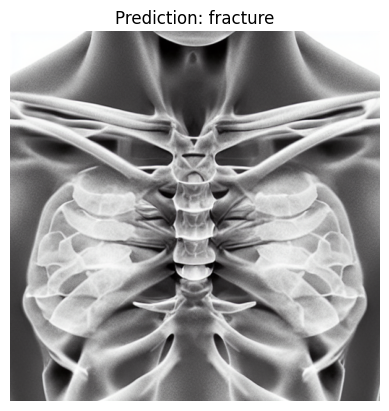

In [ ]:
img = Image.open(test_image)
plt.imshow(img, cmap="gray")
plt.title(f"Prediction: {prediction}")
plt.axis("off")
